In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Optional: Apply the default seaborn theme for better styling
sns.set_theme() 

In [2]:
file_name = "Housing.csv"

data = pd.read_csv(file_name)

df = pd.DataFrame(data)

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


<Axes: xlabel='area', ylabel='price'>

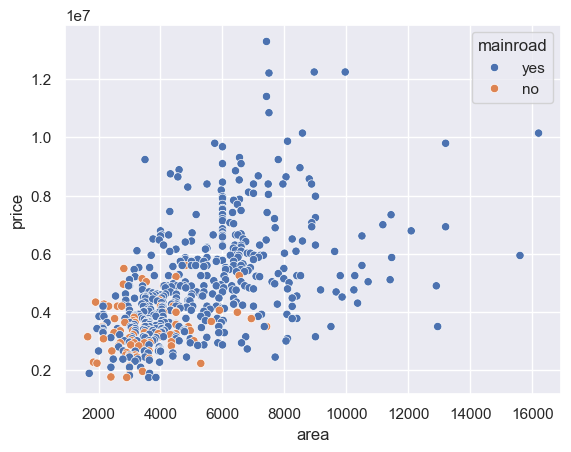

In [3]:
sns.scatterplot(x=df.loc[:, "area"], y=df.loc[:, "price"], hue=df.loc[:, "mainroad"])
#sns.scatterplot?

<Axes: xlabel='area', ylabel='price'>

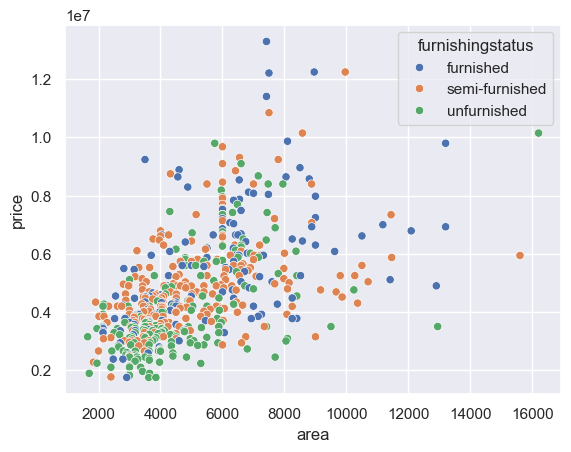

In [4]:
sns.scatterplot(x=df.loc[:, "area"], y=df.loc[:, "price"], hue=df.loc[:, "furnishingstatus"])
#sns.scatterplot?

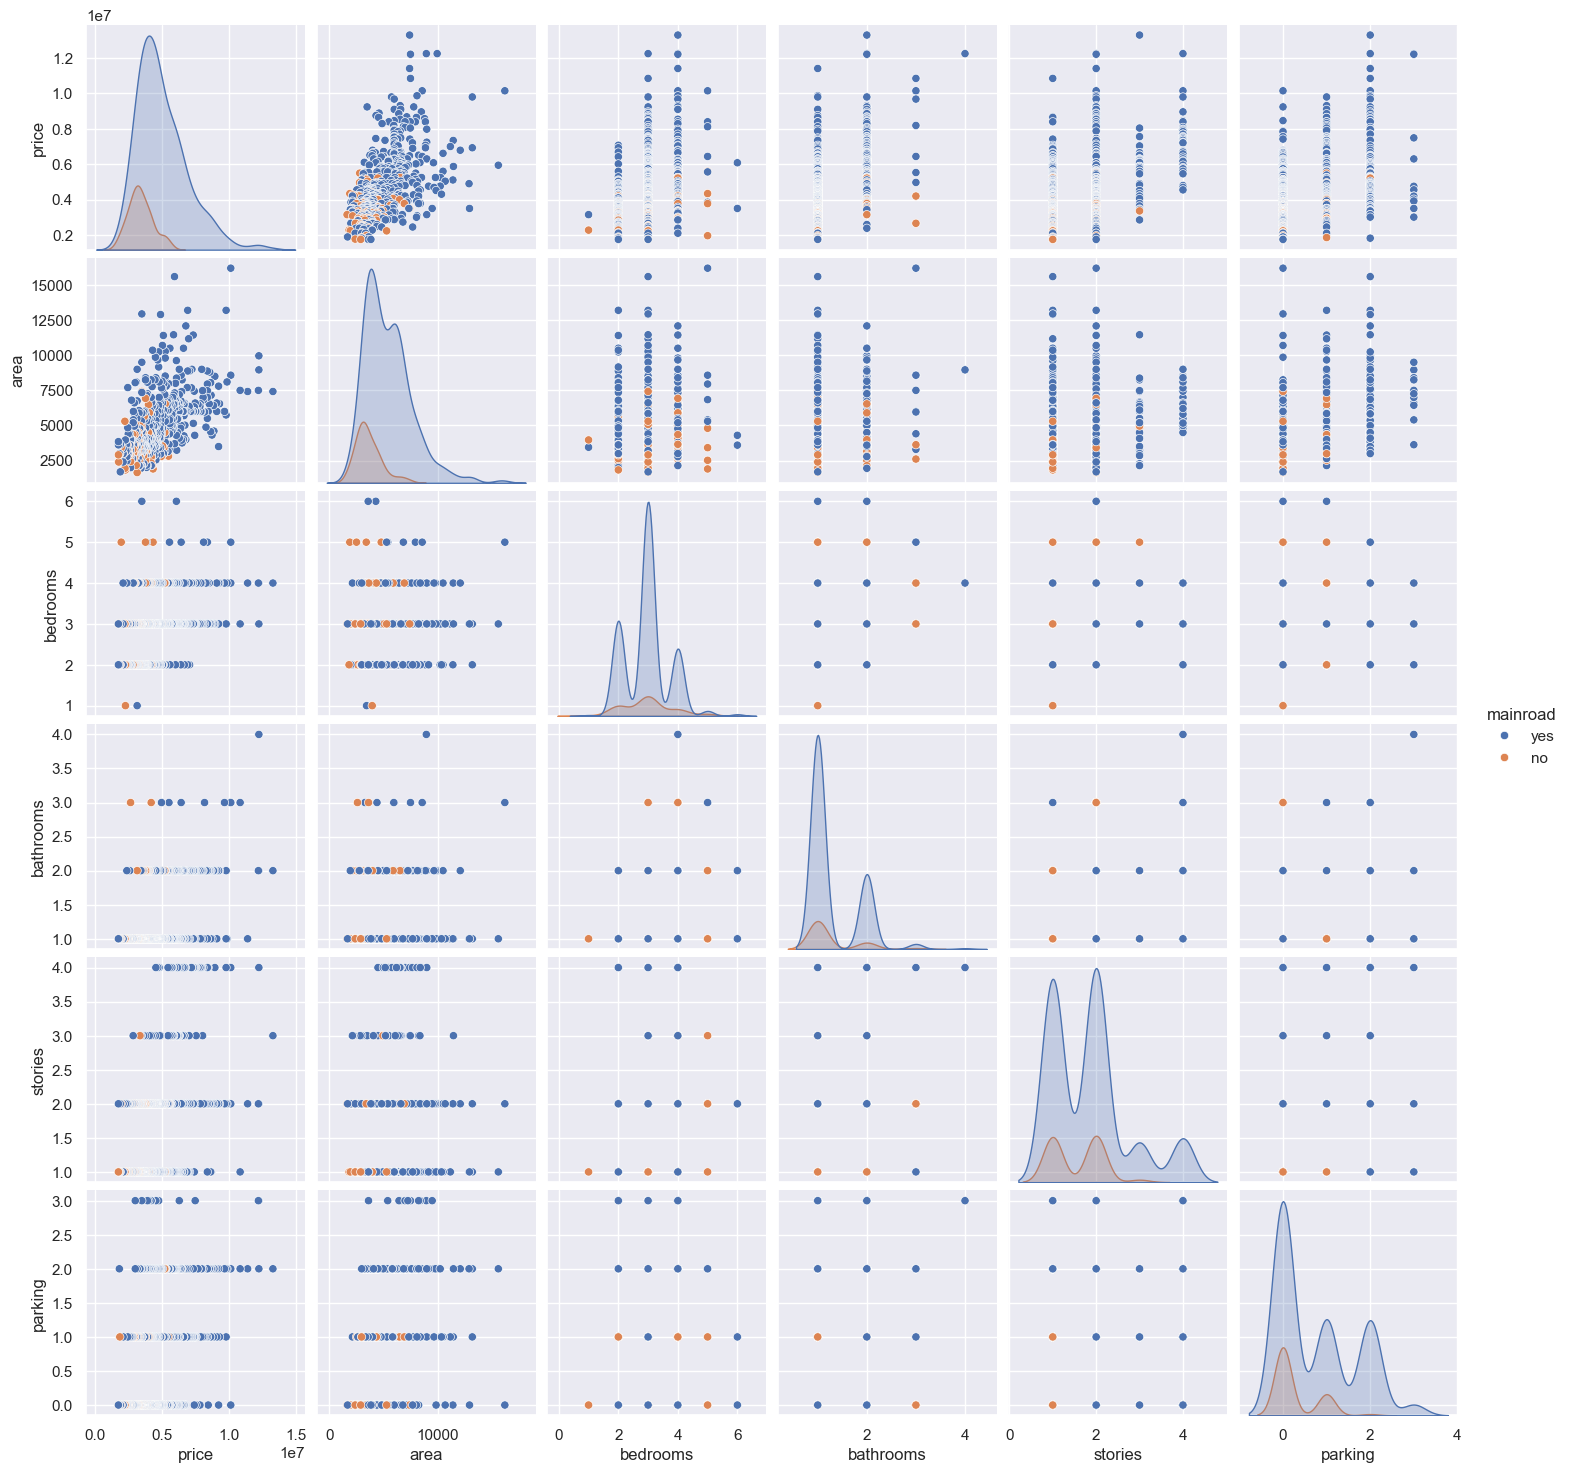

In [5]:
sns.pairplot(df, hue="mainroad")
# Save the plot as a PNG (Must be before plt.show())
plt.savefig("my_seaborn_plot.png", dpi=300, bbox_inches="tight")

# Display the plot (Optional)
plt.show()

<Axes: >

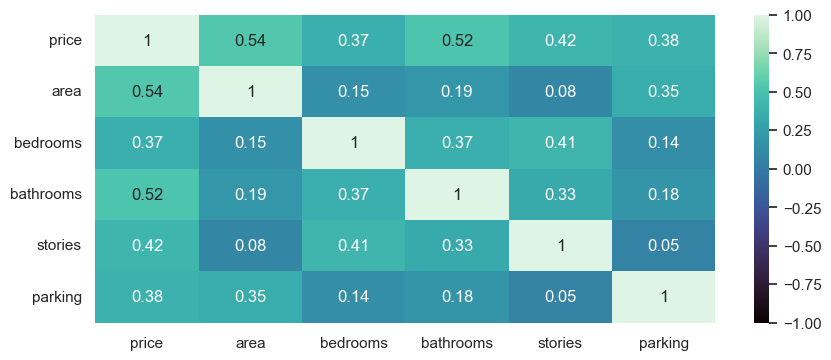

In [6]:
#correlation matrix

numeric_data =df[["price", "area", "bedrooms", "bathrooms", "stories", "parking"]].copy()

correlation = numeric_data.corr().round(2)

plt.figure(figsize=(10, 4))

plt.savefig("correlation_plot.png", dpi=300, bbox_inches="tight")

#cmpa [vlag, seismic, coolwarm, viridis, mako, crest
sns.heatmap(correlation, annot=True, cmap="mako", vmin=-1, vmax=1)

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [8]:
# Define features (X) and target (y)
X = df[['area', 'bedrooms', 'bathrooms', 'stories', 'parking']].values
y = df['price'].values

# Split the data
# test_size=0.2 means 20% of data goes to testing, 80% to training
# random_state=42 ensures the split is reproducible
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=30)

# Fit the model using ONLY the training data
model = LinearRegression(n_jobs=10)
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",10
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [9]:
model.predict([[5891, 3, 3, 2, 1]])

array([7288018.14278651])

In [10]:
y_model_train = model.predict(X_train)
y_model_test = model.predict(X_test)

In [11]:
#R squared 
from sklearn.metrics import r2_score as R2
import numpy as np

In [12]:
print(R2(y_train, y_model_train))
print(R2(y_test, y_model_test))

0.5841790090427779
0.4578472234309612


In [13]:
#features engineering
from sklearn.preprocessing import StandardScaler

In [14]:
#transform into a 2d array
y = y.reshape(len(y), 1)

In [15]:
#transforming dataset
sc_x = StandardScaler()
sc_y = StandardScaler()

X = sc_x.fit_transform(X)
y = sc_y.fit_transform(y)

# random_state=42 ensures the split is reproducible
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, )

# Fit the model using ONLY the training data
model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [16]:
#inverse new predictions
sc_y.inverse_transform(model.predict([[5891, 3, 3, 2, 1]]).reshape(-1,1))

array([[3.9530375e+09]])

In [17]:
#R squared values
y_model_train = sc_y.inverse_transform(model.predict(X_train))
y_model_test = sc_y.inverse_transform(model.predict(X_test)) 

print(R2(sc_y.inverse_transform(y_train), y_model_train))
print(R2(sc_y.inverse_transform(y_test), y_model_test))

0.5621678833074251
0.5464062355495863


In [18]:
# showing the actual test results vs the ML model predicted results
newDataFrame = pd.DataFrame()
newDataFrame[["Test values"]] = sc_y.inverse_transform(y_test)
newDataFrame[["predicted values"]] = y_model_test

print(newDataFrame)

     Test values  predicted values
0      4060000.0      6.178628e+06
1      6650000.0      6.370141e+06
2      3710000.0      3.283148e+06
3      6440000.0      4.226008e+06
4      2800000.0      3.409686e+06
..           ...               ...
104    9100000.0      5.361443e+06
105    3773000.0      5.311029e+06
106    7910000.0      7.199716e+06
107    7350000.0      6.058267e+06
108    5530000.0      5.931714e+06

[109 rows x 2 columns]


In [19]:
#note: features scaling did not affect the accuracy of the ML model
# hyperparameter tuning can increse the accuracy of this ML model

C:\Users\user\AppData\Local\Temp\ipykernel_15220\752054380.py:1: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "ro" (-> marker='o'). The keyword argument will take precedence.
  plt.plot(sc_y.inverse_transform(y_train), y_model_train, 'ro', label="Train",  marker='*')
C:\Users\user\AppData\Local\Temp\ipykernel_15220\752054380.py:2: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "bo" (-> marker='o'). The keyword argument will take precedence.
  plt.plot(sc_y.inverse_transform(y_test), y_model_test, 'bo', label="Test",  marker='+')


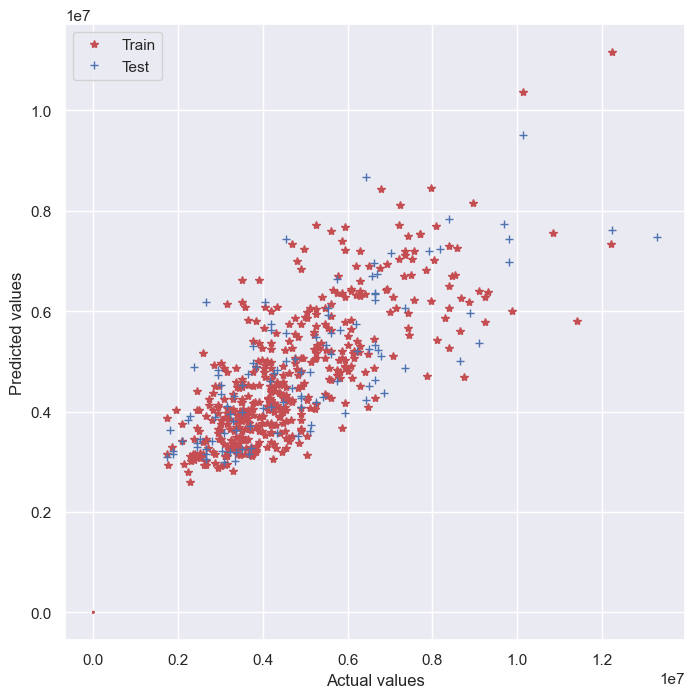

In [20]:

plt.plot(sc_y.inverse_transform(y_train), y_model_train, 'ro', label="Train",  marker='*')
plt.plot(sc_y.inverse_transform(y_test), y_model_test, 'bo', label="Test",  marker='+')

plt.plot(X, model.predict(X),
         'r--', linewidth=2)

plt.xlabel("Actual values")
plt.ylabel("Predicted values")


# plt.scatter(X, y, label='Actual Data')


plt.legend()
# plt.plot([[5891, 3, 3, 2, 1]], model.predict([[5891, 3, 3, 2, 1]]), marker='D')
fig = plt.gcf()
fig.set_size_inches(8,8)

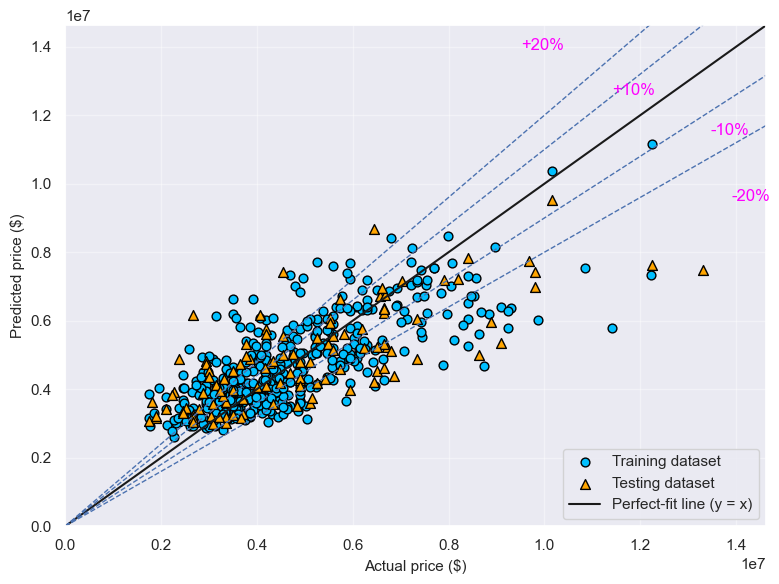

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================
# INPUT YOUR DATA HERE
# ==========================

# Actual values
y_actual_train = sc_y.inverse_transform(y_train)
y_actual_test = sc_y.inverse_transform(y_test)

# Predicted values
y_pred_train = y_model_train 
y_pred_test = y_model_test 

# ==========================
# PLOT
# ==========================
plt.figure(figsize=(8, 6))

# Scatter points
plt.scatter(y_actual_train, y_pred_train,
            color='deepskyblue',
            edgecolor='black',
            s=40,
            label='Training dataset')

plt.scatter(y_actual_test, y_pred_test,
            color='orange',
            marker='^',
            edgecolor='black',
            s=50,
            label='Testing dataset')

# Axis limits
max_val = max(
    np.max(y_actual_train),
    np.max(y_actual_test),
    np.max(y_pred_train),
    np.max(y_pred_test)
) * 1.1

x = np.linspace(0, max_val, 100)

# Perfect fit line (y=x)
plt.plot(x, x, 'k-', linewidth=1.5, label='Perfect-fit line (y = x)')

# Error bands
plt.plot(x, 1.10*x, 'b--', linewidth=1)
plt.plot(x, 0.90*x, 'b--', linewidth=1)

plt.plot(x, 1.20*x, 'b--', linewidth=1)
plt.plot(x, 0.80*x, 'b--', linewidth=1)

# Labels for error bands
plt.text(max_val*0.78, max_val*0.86, '+10%', color='magenta')
plt.text(max_val*0.92, max_val*0.78, '-10%', color='magenta')

plt.text(max_val*0.65, max_val*0.95, '+20%', color='magenta')
plt.text(max_val*0.95, max_val*0.65, '-20%', color='magenta')

# Formatting
plt.xlabel('Actual price ($)', fontsize=11)
plt.ylabel('Predicted price ($)', fontsize=11)

# plt.title('Categorical Boosting Regression', fontsize=12)

plt.grid(True, linestyle='-', alpha=0.4)
plt.legend(loc='lower right')

plt.xlim(0, max_val)
plt.ylim(0, max_val)

plt.tight_layout()
plt.show()